# <center> Taller: Auditoría de Desempeño para Negocios Digitales </center>

#PARTE 1: Simulación de Datos y Análisis de Rentabilidad

In [13]:
import pandas as pd
import numpy as np

# Generar datos simulados
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)
df

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,Web Desktop,Transferencia,169,Hogar
1,1002,Web Desktop,Transferencia,296,Electrónica
2,1003,App Móvil,Tarjeta Crédito,217,Electrónica
3,1004,Web Desktop,PayPal,89,Hogar
4,1005,App Móvil,PayPal,131,Electrónica
5,1006,App Móvil,PayPal,23,Moda
6,1007,App Móvil,Transferencia,369,Moda
7,1008,App Móvil,Transferencia,350,Moda
8,1009,App Móvil,Transferencia,465,Electrónica
9,1010,Web Desktop,Tarjeta Crédito,337,Moda


In [30]:
# PARTE 1: DETERMINACIÓN DE KPIS PARA EL MIS

print("REPORTES DE KPIS PARA LA TOMA DE DECISIONES\n")

# KPI 1: Ingreso Total Neto por Canal de Venta
# Pregunta clave: ¿Qué estrategia genera mayor volumen de dinero bruto?
kpi_ingreso_total = df.groupby('Canal')['Total_Venta'].sum().reset_index()
kpi_ingreso_total.columns = ['Canal', 'Ingreso_Total_USD']
print("KPI 1: INGRESO TOTAL POR CANAL:")
for index, row in kpi_ingreso_total.iterrows():
    print(f" * {row['Canal']}: ${row['Ingreso_Total_USD']:,}")


REPORTES DE KPIS PARA LA TOMA DE DECISIONES

KPI 1: INGRESO TOTAL POR CANAL:
 * App Móvil: $7,220
 * Web Desktop: $5,003


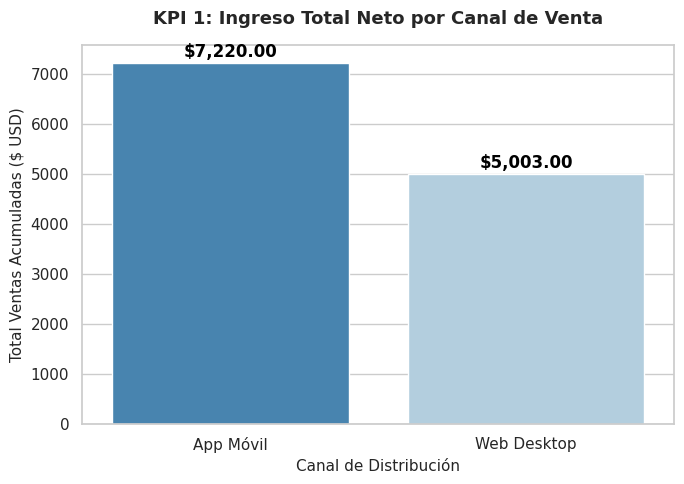

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns  # Corrección aquí

# 1. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

# 2. Crear la barra comparativa usando los datos calculados en tu variable
ax = sns.barplot(
    x='Canal',
    y='Ingreso_Total_USD',
    data=kpi_ingreso_total,
    palette='Blues_r',
    hue='Canal',
    legend=False
)

# 3. Personalizar títulos y etiquetas para el reporte gerencial (MIS)
plt.title('KPI 1: Ingreso Total Neto por Canal de Venta', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Canal de Distribución', fontsize=11)
plt.ylabel('Total Ventas Acumuladas ($ USD)', fontsize=11)

# 4. Añadir etiquetas con el valor exacto encima de cada barra
for p in ax.patches:
    ax.annotate(
        f"${p.get_height():,.2f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontweight='bold',
        color='black'
    )

# 5. Ajustar márgenes y mostrar la gráfica
plt.tight_layout()
plt.show()

In [23]:
# KPI 2: Volumen y Participación de Transacciones (Frecuencia de Compra)
# Pregunta clave: ¿En qué plataforma prefiere transaccionar el usuario común?
kpi_volumen = df['Canal'].value_counts().reset_index()
kpi_volumen.columns = ['Canal', 'Numero_Transacciones']
kpi_volumen['Participacion_%'] = (kpi_volumen['Numero_Transacciones'] / len(df)) * 100
print("KPI 2: VOLUMEN Y PARTICIPACIÓN DE TRANSACCIONES:")
for index, row in kpi_volumen.iterrows():
    print(f" * {row['Canal']}: {row['Numero_Transacciones']} órdenes ({row['Participacion_%']:.1f}%)")
print("-" * 60)

KPI 2: VOLUMEN Y PARTICIPACIÓN DE TRANSACCIONES:
 * App Móvil: 29 órdenes (58.0%)
 * Web Desktop: 21 órdenes (42.0%)
------------------------------------------------------------


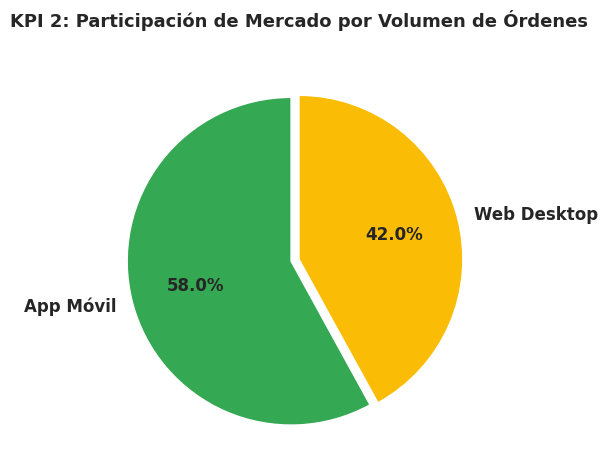

In [24]:
import matplotlib.pyplot as plt

# 1. Configurar el tamaño del gráfico
plt.figure(figsize=(6, 6))

# 2. Definir los colores corporativos para el reporte
colores = ['#34a853', '#fbbc05']

# 3. Crear el gráfico de pastel usando los datos de tu variable 'kpi_volumen'
plt.pie(
    kpi_volumen['Numero_Transacciones'],
    labels=kpi_volumen['Canal'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colores,
    explode=(0.05, 0),
    textprops={'weight': 'bold', 'fontsize': 12}
)

# 4. Añadir el título del KPI
plt.title('KPI 2: Participación de Mercado por Volumen de Órdenes', fontsize=13, fontweight='bold', pad=20)

# 5. Mostrar la gráfica
plt.tight_layout()
plt.show()

In [25]:
# KPI 3: Ticket Promedio por Transacción (AOV - Average Order Value)
# Pregunta clave: Cuando el cliente compra, ¿en qué canal gasta más por factura?
kpi_ticket_promedio = df.groupby('Canal')['Total_Venta'].mean().reset_index()
kpi_ticket_promedio.columns = ['Canal', 'Ticket_Promedio_USD']
print("KPI 3: TICKET PROMEDIO POR CANAL:")
for index, row in kpi_ticket_promedio.iterrows():
    print(f" * {row['Canal']}: ${row['Ticket_Promedio_USD']:.2f}")
print("-" * 60)

KPI 3: TICKET PROMEDIO POR CANAL:
 * App Móvil: $248.97
 * Web Desktop: $238.24
------------------------------------------------------------


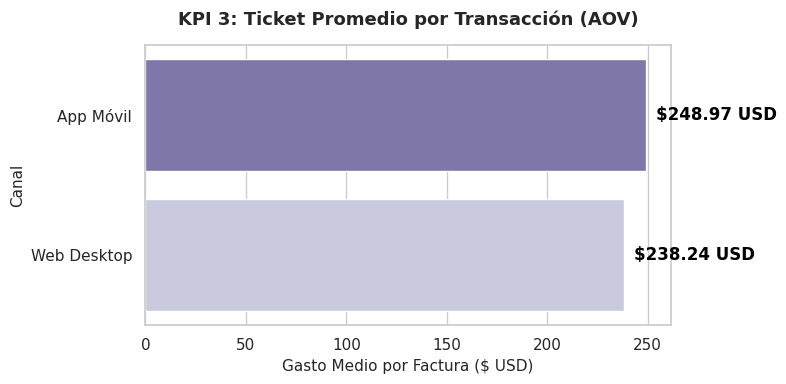

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar tamaño y estilo
plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")

# 2. Crear barras horizontales basadas en tu variable kpi_ticket_promedio
ax = sns.barplot(
    x='Ticket_Promedio_USD',
    y='Canal',
    data=kpi_ticket_promedio,
    palette='Purples_r',  # Tono púrpura elegante para diferenciarlo de los anteriores
    hue='Canal',
    legend=False
)

# 3. Títulos y etiquetas de control gerencial
plt.title('KPI 3: Ticket Promedio por Transacción (AOV)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Gasto Medio por Factura ($ USD)', fontsize=11)
plt.ylabel('Canal', fontsize=11)

# 4. Añadir las etiquetas de valor al final de cada barra horizontal
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 5,                # Posición un poco más a la derecha del final de la barra
        p.get_y() + p.get_height() / 2, # Centrado verticalmente en la barra
        f"${width:.2f} USD",
        ha='left',
        va='center',
        fontweight='bold',
        color='black'
    )

# 5. Ajustar márgenes y desplegar
plt.tight_layout()
plt.show()

In [29]:
# KPI 4: Matriz de Preferencia de Categorías e Impacto Financiero
# Pregunta clave: ¿Qué tipo de productos impulsan el éxito de cada canal?
kpi_matriz_cat = pd.crosstab(df['Canal'], df['Categoria'], values=df['Total_Venta'], aggfunc='sum').fillna(0)
print("KPI 4: DISTRIBUCIÓN DE VENTAS (USD) POR CATEGORÍA Y CANAL:")
print(kpi_matriz_cat.round(2))

KPI 4: DISTRIBUCIÓN DE VENTAS (USD) POR CATEGORÍA Y CANAL:
Categoria    Electrónica  Hogar  Moda
Canal                                
App Móvil           2785   2657  1778
Web Desktop         1590   1588  1825


<Figure size 1000x600 with 0 Axes>

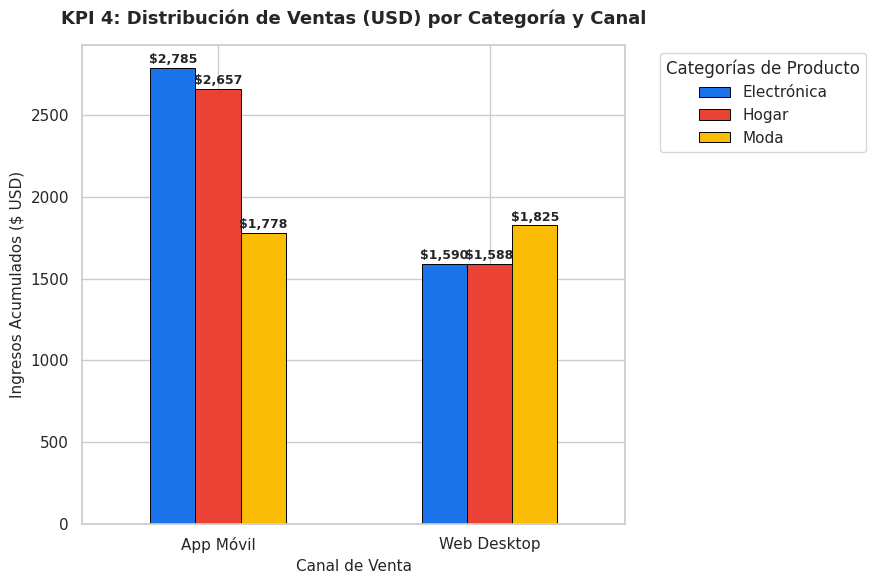

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar tamaño y estilo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Graficar directamente desde la matriz cruzada de Pandas
# Usamos columnas como barras agrupadas con colores ejecutivos
ax = kpi_matriz_cat.plot(
    kind='bar',
    figsize=(9, 6),
    color=['#1a73e8', '#ea4335', '#fabc05'], # Azul para Electrónica, Rojo para Hogar, Amarillo para Moda
    edgecolor='black',
    linewidth=0.7
)

# 3. Personalizar títulos, leyendas y etiquetas del MIS
plt.title('KPI 4: Distribución de Ventas (USD) por Categoría y Canal', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Canal de Venta', fontsize=11)
plt.ylabel('Ingresos Acumulados ($ USD)', fontsize=11)
plt.xticks(rotation=0) # Mantener los nombres de los canales horizontales
plt.legend(title='Categorías de Producto', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Añadir las etiquetas de los valores en dólares sobre cada barra de forma dinámica
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Evitar etiquetar barras vacías si las hubiera
        ax.annotate(
            f"${height:,.0f}",
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 6),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

# 5. Ajustar márgenes para que no se corte la leyenda externa y mostrar
plt.tight_layout()
plt.show()

Analisis de Datos:
La App Móvil es el canal dominante de la organización al tener el 58% del volumen de compras y generar el mayor impacto financiero con 7,220 USD en ingresos, esto se puede ver por un ticket promedio superior (248.97 USD) impulsado fuertemente por las categorías de Electrónica y Hogar. Por otro lado, la Web Desktop mantiene un rendimiento menor (5,003 USD), pero es el canal preferido para la categoría de Moda (1,825 USD), lo que nos dice que los usuarios prefieren la plataforma de escritorio para decisiones de compra textil mientras que en el móvil lidera en transacciones tecnológicas e impulsivas.

#PARTE 2: KPIs para E-Commerce

In [19]:
import pandas as pd

# Cargar el dataset con su nombre real
data = pd.read_csv('Train.csv')

#1. KPIs de Gestión de Logística y Operaciones (Shipment & Warehouse)

In [31]:
# 1.1. Costo Promedio del Producto por Modo de Transporte
print("1.1. Costo Promedio del Producto por Modo de Transporte:")
kpi_1_1 = data.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().reset_index()
kpi_1_1.columns = ['Modo de Envío', 'Costo Promedio (USD)']
print(kpi_1_1.to_string(index=False))

1.1. Costo Promedio del Producto por Modo de Transporte:
Modo de Envío  Costo Promedio (USD)
       Flight            209.306697
         Road            210.475568
         Ship            210.343072


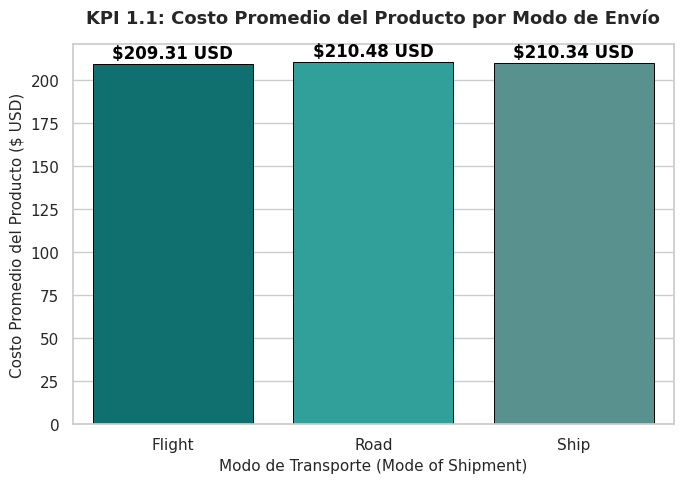

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

# Definir una paleta de colores manual segura (tonos verde-azulados)
colores_logistica = ['#008080', '#20b2aa', '#4e9a96']

# 2. Crear las barras basadas en tu variable kpi_1_1
ax = sns.barplot(
    x='Modo de Envío',
    y='Costo Promedio (USD)',
    data=kpi_1_1,
    palette=colores_logistica,  # Colores manuales sin riesgo de error
    hue='Modo de Envío',
    legend=False,
    edgecolor='black',
    linewidth=0.7
)

# 3. Personalizar títulos y etiquetas para el reporte de operaciones (MIS)
plt.title('KPI 1.1: Costo Promedio del Producto por Modo de Envío', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Modo de Transporte (Mode of Shipment)', fontsize=11)
plt.ylabel('Costo Promedio del Producto ($ USD)', fontsize=11)

# 4. Añadir etiquetas de valor exactas arriba de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"${height:,.2f} USD",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontweight='bold',
        color='black'
    )

# 5. Ajustar márgenes y mostrar la gráfica
plt.tight_layout()
plt.show()

In [34]:
# 1.2. Volumen de Ocupación por Bloque de Bodega (Warehouse_block)
print("1.2. Volumen de Ocupación por Bloque de Bodega:")
kpi_1_2 = data['Warehouse_block'].value_counts().reset_index()
kpi_1_2.columns = ['Bloque Bodega', 'Cantidad Productos']
kpi_1_2['Porcentaje Ocupación'] = (kpi_1_2['Cantidad Productos'] / len(data)) * 100
print(kpi_1_2.to_string(index=False))

1.2. Volumen de Ocupación por Bloque de Bodega:
Bloque Bodega  Cantidad Productos  Porcentaje Ocupación
            F                3666             33.330303
            D                1834             16.674243
            A                1833             16.665151
            B                1833             16.665151
            C                1833             16.665151


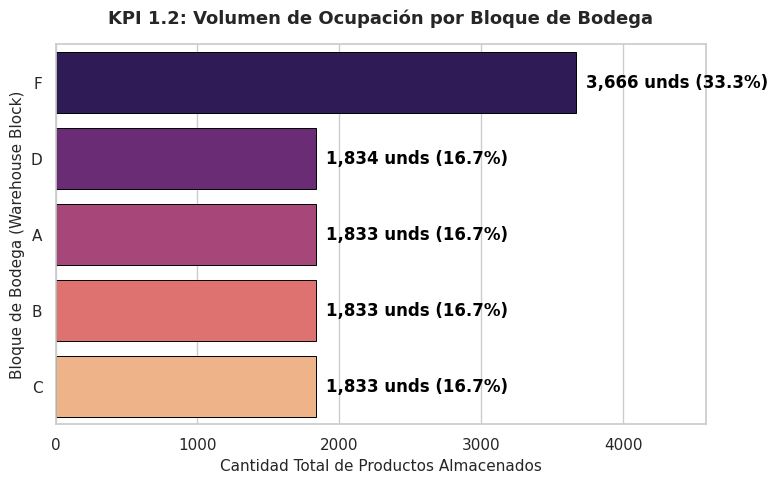

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# 2. Crear las barras horizontales ordenadas automáticamente por cantidad
ax = sns.barplot(
    x='Cantidad Productos',
    y='Bloque Bodega',
    data=kpi_1_2,
    palette='magma',  # Paleta degradada que resalta visualmente los bloques más llenos
    hue='Bloque Bodega',
    legend=False,
    edgecolor='black',
    linewidth=0.7
)

# 3. Personalizar títulos y etiquetas del MIS logístico
plt.title('KPI 1.2: Volumen de Ocupación por Bloque de Bodega', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Cantidad Total de Productos Almacenados', fontsize=11)
plt.ylabel('Bloque de Bodega (Warehouse Block)', fontsize=11)

# 4. Añadir etiquetas dinámicas con la cantidad y el porcentaje de ocupación al final de cada barra
for p in ax.patches:
    width = p.get_width()
    # Calcular el porcentaje dinámicamente basado en la cantidad de la barra
    porcentaje = (width / len(data)) * 100

    ax.text(
        width + (max(kpi_1_2['Cantidad Productos']) * 0.02),  # Pequeño margen a la derecha
        p.get_y() + p.get_height() / 2,
        f"{int(width):,} unds ({porcentaje:.1f}%)",
        ha='left',
        va='center',
        fontweight='bold',
        color='black'
    )

# 5. Ajustar márgenes para dar espacio a las etiquetas de texto externas
plt.xlim(0, max(kpi_1_2['Cantidad Productos']) * 1.25)
plt.tight_layout()
plt.show()

In [36]:
# 1.3. Peso Promedio del Producto por Modo de Envío (Corregido con 'Weight_in_gms')
print("1.3. Peso Promedio del Producto por Modo de Envío:")
kpi_1_3 = data.groupby('Mode_of_Shipment')['Weight_in_gms'].mean().reset_index()
kpi_1_3.columns = ['Modo de Envío', 'Peso Promedio (Gramos)']
print(kpi_1_3.to_string(index=False))

1.3. Peso Promedio del Producto por Modo de Envío:
Modo de Envío  Peso Promedio (Gramos)
       Flight             3629.378165
         Road             3649.550568
         Ship             3631.457518


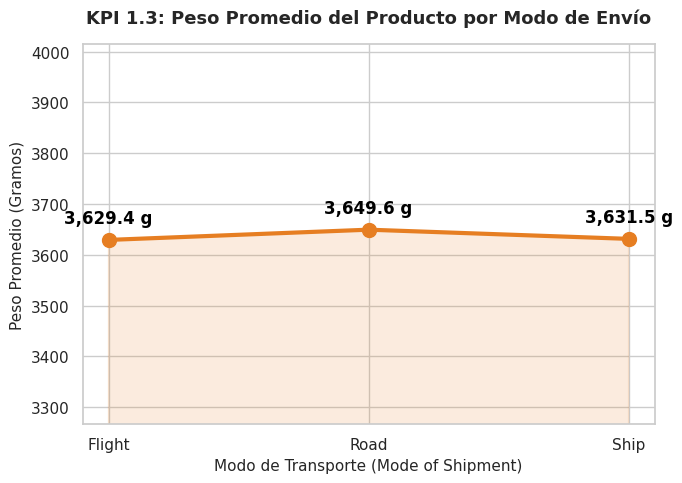

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

# 2. Graficar la línea de tendencia del peso por modo de envío
plt.plot(
    kpi_1_3['Modo de Envío'],
    kpi_1_3['Peso Promedio (Gramos)'],
    color='#e67e22',       # Color naranja llamativo para operaciones
    marker='o',            # Marcador circular en cada punto
    linewidth=3,           # Grosor de la línea
    markersize=10,         # Tamaño del punto
    label='Peso Promedio'
)

# Rellenar sutilmente el área debajo de la línea para darle un acabado moderno
plt.fill_between(
    kpi_1_3['Modo de Envío'],
    kpi_1_3['Peso Promedio (Gramos)'],
    color='#e67e22',
    alpha=0.15
)

# 3. Personalizar títulos y etiquetas para el MIS
plt.title('KPI 1.3: Peso Promedio del Producto por Modo de Envío', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Modo de Transporte (Mode of Shipment)', fontsize=11)
plt.ylabel('Peso Promedio (Gramos)', fontsize=11)

# 4. Añadir etiquetas con el valor numérico exacto encima de cada marcador
for i, row in kpi_1_3.iterrows():
    plt.annotate(
        f"{row['Peso Promedio (Gramos)']:,.1f} g",
        (row['Modo de Envío'], row['Peso Promedio (Gramos)']),
        textcoords="offset points",
        xytext=(0, 12),       # Desplazar el texto hacia arriba del punto
        ha='center',
        fontweight='bold',
        color='black'
    )

# Ajustar el límite vertical para dar espacio a las etiquetas de texto superiores
plt.ylim(min(kpi_1_3['Peso Promedio (Gramos)']) * 0.9, max(kpi_1_3['Peso Promedio (Gramos)']) * 1.1)

# 5. Mostrar la gráfica de manera limpia
plt.tight_layout()
plt.show()

Análisis de Logística y Operaciones:
El ecosistema logístico muestra una distribución de inventario enfocada principalmente en el Bloque F, el cual tiene el 33.3% de la ocupación global (3,666 unidades), duplicando la carga operativa de cualquiera de los demás bloques (A, B, C y D) que se mantienen perfectamente equilibrados en torno al 16.6% cada uno. En cuanto a la distribución por canales de transporte, la estrategia de asignación es muy homogénea, ya que tanto el costo promedio del producto (estabilizado cerca de los 210 USD para Flight, Road y Ship) como el peso promedio de la carga (variando entre 3,629 y 3,649 gramos) no presentan variaciones significativas entre vías aéreas, marítimas o terrestres, lo que sugiere un modelo de distribución estandarizado.

#2. KPIs de Gestión Comercial y Financiera (Sales & Revenue)

In [38]:
# 2.1. Ingreso Total Bruto y Costo Promedio
ingreso_total = data['Cost_of_the_Product'].sum()
costo_promedio = data['Cost_of_the_Product'].mean()
print("2.1. Análisis de Costos e Ingreso Evaluado:")
print(f" * Ingreso Bruto Evaluado (Suma de Costos): ${ingreso_total:,} USD")
print(f" * Costo Promedio por Producto: ${costo_promedio:.2f} USD")

2.1. Análisis de Costos e Ingreso Evaluado:
 * Ingreso Bruto Evaluado (Suma de Costos): $2,311,955 USD
 * Costo Promedio por Producto: $210.20 USD


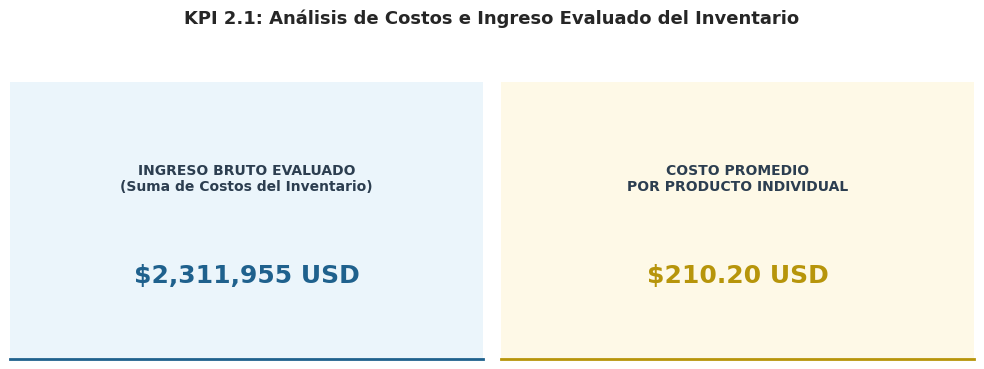

In [39]:
import matplotlib.pyplot as plt

# 1. Crear el lienzo para las tarjetas de control
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
fig.suptitle('KPI 2.1: Análisis de Costos e Ingreso Evaluado del Inventario', fontsize=13, fontweight='bold', y=1.05)

# --- TARJETA 1: INGRESO BRUTO EVALUADO ---
ax1.set_facecolor('#ebf5fb') # Fondo azul claro corporativo
ax1.text(0.5, 0.65, 'INGRESO BRUTO EVALUADO\n(Suma de Costos del Inventario)',
         fontsize=10, fontweight='bold', color='#2c3e50', ha='center', va='center')
ax1.text(0.5, 0.3, f"${ingreso_total:,} USD",
         fontsize=18, fontweight='bold', color='#1f618d', ha='center', va='center')
# Limpiar ejes de la tarjeta
ax1.set_xticks([])
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_color('#1f618d')
ax1.spines['bottom'].set_linewidth(2)

# --- TARJETA 2: COSTO PROMEDIO POR PRODUCTO ---
ax2.set_facecolor('#fef9e7') # Fondo amarillo/crema claro corporativo
ax2.text(0.5, 0.65, 'COSTO PROMEDIO\nPOR PRODUCTO INDIVIDUAL',
         fontsize=10, fontweight='bold', color='#2c3e50', ha='center', va='center')
ax2.text(0.5, 0.3, f"${costo_promedio:.2f} USD",
         fontsize=18, fontweight='bold', color='#b7950b', ha='center', va='center')
# Limpiar ejes de la tarjeta
ax2.set_xticks([])
ax2.set_yticks([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_color('#b7950b')
ax2.spines['bottom'].set_linewidth(2)

# 2. Desplegar el panel de métricas de forma limpia
plt.tight_layout()
plt.show()

In [40]:
# 2.2. Porcentaje de Descuento Promedio Otorgado
print("2.2. Porcentaje de Descuento Promedio por Importancia del Producto:")
kpi_2_2 = data.groupby('Product_importance')['Discount_offered'].mean().reset_index()
kpi_2_2.columns = ['Importancia del Producto', 'Descuento Promedio (%)']
print(kpi_2_2.to_string(index=False))

2.2. Porcentaje de Descuento Promedio por Importancia del Producto:
Importancia del Producto  Descuento Promedio (%)
                    high               14.666667
                     low               13.043043
                  medium               13.483172


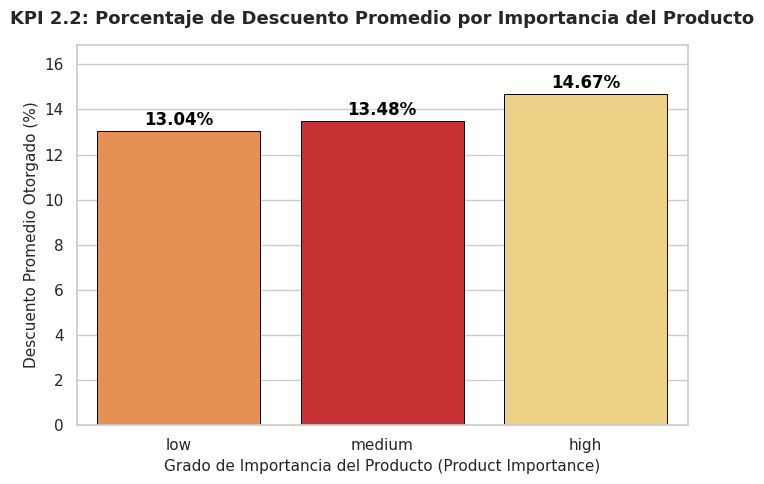

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar el orden lógico de las categorías para el análisis comercial
orden_importancia = ['low', 'medium', 'high']

# 2. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

# 3. Crear las barras basadas en tu variable kpi_2_2
ax = sns.barplot(
    x='Importancia del Producto',
    y='Descuento Promedio (%)',
    data=kpi_2_2,
    order=orden_importancia,  # Fuerza el orden comercial correcto
    palette='YlOrRd',          # Degradado cálido (Amarillo-Naranja-Rojo) corporativo
    hue='Importancia del Producto',
    legend=False,
    edgecolor='black',
    linewidth=0.7
)

# 4. Personalizar títulos y etiquetas del MIS Financiero
plt.title('KPI 2.2: Porcentaje de Descuento Promedio por Importancia del Producto', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Grado de Importancia del Producto (Product Importance)', fontsize=11)
plt.ylabel('Descuento Promedio Otorgado (%)', fontsize=11)

# 5. Añadir las etiquetas porcentuales sobre cada columna de forma dinámica
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}%",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontweight='bold',
        color='black'
    )

# Ajustar límites y márgenes
plt.ylim(0, max(kpi_2_2['Descuento Promedio (%)']) * 1.15)
plt.tight_layout()
plt.show()

In [42]:
# 2.3. Margen Teórico Relativo (Relación de Costo y Descuento)
print("2.3. Relación de Costo y Descuento por Importancia de Producto:")
kpi_2_3 = data.groupby('Product_importance').agg({
    'Cost_of_the_Product': 'mean',
    'Discount_offered': 'mean'
}).reset_index()
kpi_2_3.columns = ['Importancia', 'Costo Promedio (USD)', 'Descuento Promedio (%)']
print(kpi_2_3.to_string(index=False))

2.3. Relación de Costo y Descuento por Importancia de Producto:
Importancia  Costo Promedio (USD)  Descuento Promedio (%)
       high            203.871308               14.666667
        low            212.059845               13.043043
     medium            209.382415               13.483172


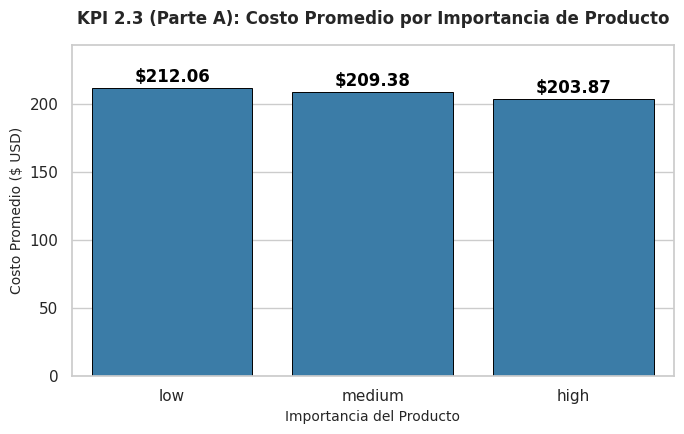

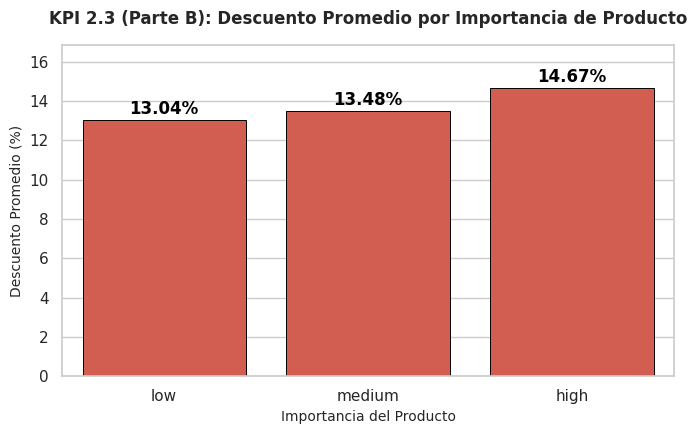

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Asegurar el orden lógico y conversión de datos
orden_importancia = ['low', 'medium', 'high']
kpi_2_3['Importancia'] = pd.Categorical(kpi_2_3['Importancia'], categories=orden_importancia, ordered=True)
kpi_2_3 = kpi_2_3.sort_values('Importancia')

sns.set_theme(style="whitegrid")

# GRÁFICO A: Costo Promedio por Importancia del Producto
plt.figure(figsize=(7, 4.5))

ax_costo = sns.barplot(
    x='Importancia',
    y='Costo Promedio (USD)',
    data=kpi_2_3,
    color='#2980b9',
    edgecolor='black',
    linewidth=0.7
)

plt.title('KPI 2.3 (Parte A): Costo Promedio por Importancia de Producto', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Importancia del Producto', fontsize=10)
plt.ylabel('Costo Promedio ($ USD)', fontsize=10)
plt.ylim(0, max(kpi_2_3['Costo Promedio (USD)']) * 1.15)

# Añadir etiquetas de valor exacto arriba de cada barra de forma segura
for p in ax_costo.patches:
    height = p.get_height()
    ax_costo.annotate(
        f"${height:,.2f}",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

print("\n" + "="*70 + "\n") # Separador visual

# GRÁFICO B: Descuento Promedio por Importancia del Producto
plt.figure(figsize=(7, 4.5))

ax_desc = sns.barplot(
    x='Importancia',
    y='Descuento Promedio (%)',
    data=kpi_2_3,
    color='#e74c3c',
    edgecolor='black',
    linewidth=0.7
)

plt.title('KPI 2.3 (Parte B): Descuento Promedio por Importancia de Producto', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Importancia del Producto', fontsize=10)
plt.ylabel('Descuento Promedio (%)', fontsize=10)
plt.ylim(0, max(kpi_2_3['Descuento Promedio (%)']) * 1.15)

# Añadir etiquetas con el porcentaje exacto arriba de cada barra de forma segura
for p in ax_desc.patches:
    height = p.get_height()
    ax_desc.annotate(
        f"{height:.2f}%",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

Análisis Comercial y Financiero:
La valoración económica del inventario refleja un ingreso bruto evaluado de  2,311,955 USD, manteniendo un costo promedio estandarizado de  210.20 USD por producto individual. Al revisar la estrategia comercial, se ve algo importante en sus descuentos: los productos catalogados con alta importancia (high) registran el costo de adquisición más bajo ( 203.87 USD) pero reciben la reducción de precio más agresiva con un 14.67% de descuento promedio. Los artículos de baja prioridad (low) tienen el costo base más alto ( 212.06 USD) y el menor margen de rebaja (13.04%), lo que nos muestra que la organización está sacrificando sin razon alguna el margen de ganancia en sus productos de mayor demanda en lugar de usar los descuentos estratégicamente.

#3. KPIs de Experiencia y Fidelización del Cliente (Customer Experience - CX)

In [48]:
# 3.1. Índice de Satisfacción del Cliente (CSAT) Promedio por Género
print("3.1. Índice de Satisfacción (CSAT Promedio) Segmentado por Género:")
kpi_3_1 = data.groupby('Gender')['Customer_rating'].mean().reset_index()
kpi_3_1.columns = ['Género', 'CSAT Promedio (1-5)']
print(kpi_3_1.to_string(index=False))

3.1. Índice de Satisfacción (CSAT Promedio) Segmentado por Género:
Género  CSAT Promedio (1-5)
     F             2.986655
     M             2.994499


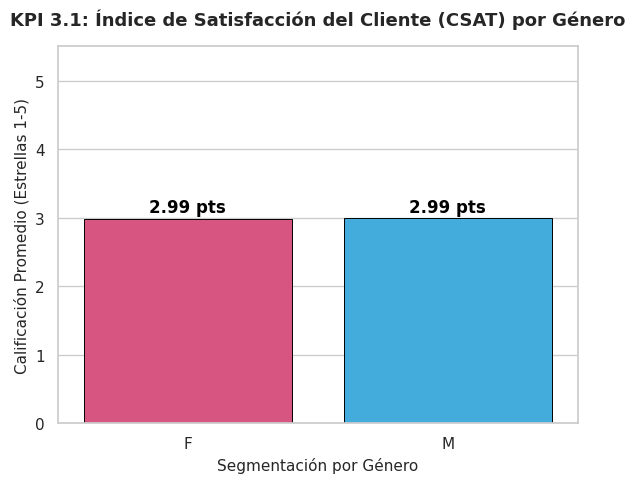

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(6, 5))
sns.set_theme(style="whitegrid")

# Definir colores corporativos para la segmentación de género
colores_genero = ['#ec407a', '#29b6f6'] # Rosa para F (Female), Azul para M (Male)

# 2. Crear las barras basadas en tu variable kpi_3_1
ax = sns.barplot(
    x='Género',
    y='CSAT Promedio (1-5)',
    data=kpi_3_1,
    palette=colores_genero,
    hue='Género',
    legend=False,
    edgecolor='black',
    linewidth=0.7
)

# 3. Personalizar títulos y etiquetas para el análisis de experiencia (CSAT)
plt.title('KPI 3.1: Índice de Satisfacción del Cliente (CSAT) por Género', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Segmentación por Género', fontsize=11)
plt.ylabel('Calificación Promedio (Estrellas 1-5)', fontsize=11)

# Forzar el eje Y de 0 a 5 para reflejar la escala real de la encuesta de satisfacción
plt.ylim(0, 5.5)

# 4. Añadir las etiquetas con el promedio exacto arriba de cada columna de forma segura
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f} pts",  # <-- Cambiado '⭐' por 'pts' para evitar el error de fuente
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontweight='bold',
        color='black'
    )

# 5. Ajustar márgenes y mostrar la gráfica
plt.tight_layout()
plt.show()

In [50]:
# 3.2. Tasa de Retención / Clientes Recurrentes
data['Tipo_Cliente'] = data['Prior_purchases'].apply(lambda x: 'Nuevo (<= 3 compras)' if x <= 3 else 'Fidelizado (4+ compras)')
kpi_3_2 = data['Tipo_Cliente'].value_counts(normalize=True) * 100
print("3.2. Distribución y Fidelidad de los Clientes (Prior_purchases):")
for tipo, porc in kpi_3_2.items():
    print(f" * {tipo}: {porc:.1f}% de la base de datos")

3.2. Distribución y Fidelidad de los Clientes (Prior_purchases):
 * Nuevo (<= 3 compras): 59.6% de la base de datos
 * Fidelizado (4+ compras): 40.4% de la base de datos


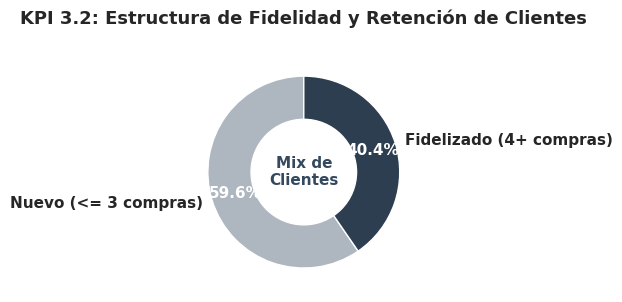

In [51]:
import matplotlib.pyplot as plt

# 1. Configurar el tamaño del gráfico
plt.figure(figsize=(6, 6))

# Definir colores ejecutivos (Azul oscuro para fidelizados, Gris/Azul claro para nuevos)
colores_retencion = ['#2c3e50', '#aeb6bf'] if kpi_3_2.index[0] == 'Fidelizado (4+ compras)' else ['#aeb6bf', '#2c3e50']

# 2. Crear el gráfico de pastel base
wedges, texts, autotexts = plt.pie(
    kpi_3_2.values,
    labels=kpi_3_2.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colores_retencion,
    pctdistance=0.75,
    textprops={'fontsize': 11, 'weight': 'bold'}
)

# Cambiar el color de los porcentajes internos a blanco para que contrasten bien
for autotext in autotexts:
    autotext.set_color('white')

# 3. Transformarlo en dona dibujando un círculo blanco en el centro (orificio)
centre_circle = plt.Circle((0,0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 4. Personalizar títulos e incluir un texto en el centro de la dona
plt.title('KPI 3.2: Estructura de Fidelidad y Retención de Clientes', fontsize=13, fontweight='bold', pad=20)

# Añadir una etiqueta corta en el centro del hueco
plt.text(0, 0, 'Mix de\nClientes', ha='center', va='center', fontsize=11, fontweight='bold', color='#34495e')

# 5. Desplegar de forma limpia
plt.tight_layout()
plt.show()

In [52]:
# 3.3. Carga de Soporte por Cliente (Llamadas vs Calificación)
print("3.3. Promedio de Llamadas de Soporte según la Calificación del Cliente:")
kpi_3_3 = data.groupby('Customer_rating')['Customer_care_calls'].mean().reset_index()
kpi_3_3.columns = ['Calificación (Customer_rating)', 'Promedio de Llamadas de Soporte']
print(kpi_3_3.to_string(index=False))

3.3. Promedio de Llamadas de Soporte según la Calificación del Cliente:
 Calificación (Customer_rating)  Promedio de Llamadas de Soporte
                              1                         4.036242
                              2                         4.048961
                              3                         4.058062
                              4                         4.038831
                              5                         4.090742


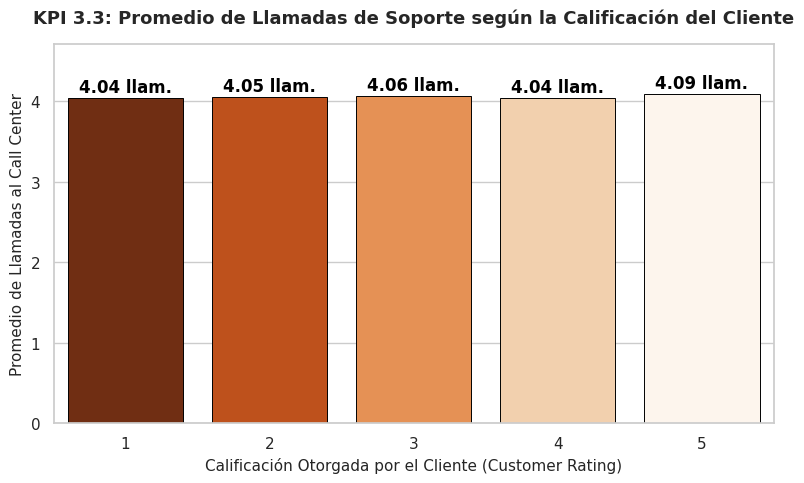

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# 2. Crear las barras basadas en tu variable kpi_3_3
ax = sns.barplot(
    x='Calificación (Customer_rating)',
    y='Promedio de Llamadas de Soporte',
    data=kpi_3_3,
    palette='Oranges_r',  # Degradado de naranja a claro, ideal para alertar carga de soporte
    hue='Calificación (Customer_rating)',
    legend=False,
    edgecolor='black',
    linewidth=0.7
)

# 3. Personalizar títulos y etiquetas para el análisis de operaciones y satisfacción (MIS)
plt.title('KPI 3.3: Promedio de Llamadas de Soporte según la Calificación del Cliente', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Calificación Otorgada por el Cliente (Customer Rating)', fontsize=11)
plt.ylabel('Promedio de Llamadas al Call Center', fontsize=11)

# Ajustar el límite de Y dando un margen para las etiquetas de texto superiores
plt.ylim(0, max(kpi_3_3['Promedio de Llamadas de Soporte']) * 1.15)

# 4. Añadir etiquetas dinámicas con el valor exacto encima de cada barra de forma segura
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f} llam.",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontweight='bold',
        color='black'
    )

# 5. Ajustar márgenes y mostrar la gráfica
plt.tight_layout()
plt.show()

Análisis de Experiencia y Fidelización del Cliente:
Los indicadores de experiencia muestran una base de datos compuesta principalmente por clientes Nuevos (59.6%), mientras que el segmento Fidelizado representa el 40.4% restantes, lo que plantea la necesidad de estrategias de retención a largo plazo. Al evaluar la percepción del servicio (CSAT), la satisfacción promedio se mantiene en un nivel regular y sumamente homogéneo entre géneros, registrando 2.99 estrellas en hombres y 2.98 estrellas en mujeres. Esta calificación intermedia se encuentra fuertemente correlacionada con una alta fricción en el servicio postventa; independientemente de si el cliente otorga la nota más baja de 1 estrella o la más alta de 5 estrellas, el promedio de llamadas de soporte se mantiene saturado de forma lineal entre 4.03 y 4.09 llamadas por usuario, demostrando que incluso los clientes más leales o satisfechos requieren un esfuerzo operativo idéntico y excesivo por parte del área de atención al cliente para resolver sus requerimientos.